In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#df = pd.read_fwf('datos.txt')
data=np.genfromtxt('datosdescargahelio.txt',dtype='float')
#data[:,1]

In [7]:
lam=data[:,0]*(10**(-9))
fac=(1/(3*(10**8)))*np.multiply(lam,lam)
#%Pasamos al espectro en frecuencias y normalizamos
sp_f=np.multiply(fac,data[:,1] ) 
sp_f_norm=np.divide(sp_f,np.max(sp_f)) #espectro en frecuencias normalizado
#Calculamos la función de coherencia mutua aplicando W-K, asumiento que el % espectro en frecuencias es la TF de la señal temporal
FCM=np.fft.ifft(np.multiply(sp_f_norm,sp_f_norm ))#nos da la distribucion desordenada (primera parte a la izda y la segunda  a la drcha)
#FCM=ifft(sp_f_norm);
L=len(lam)
P2 = abs(FCM/L)
P1 = P2[0:round(L/2)] #como solo nos interesa la mitad del espectro nos quedamos con la mitad del array 
P1[1:-1] = 2*P1[1:-1] #multiplicamos por dos para que al obtener la long. de coherencia no haya problema, ya que antes he quitado la mitad de la distribucion
Fs=(1/2.24*(10^12))
ts=Fs*np.arange(0,L/2)/L 

posicion=[i for i, j in enumerate(sp_f) if j == np.max(sp_f)]
print('longitud de pico se da en' ,np.max(sp_f), 'con una lambda= ',lam[posicion])

longitud de pico se da en 4.7181148224e-18 con una lambda=  [5.88e-07]


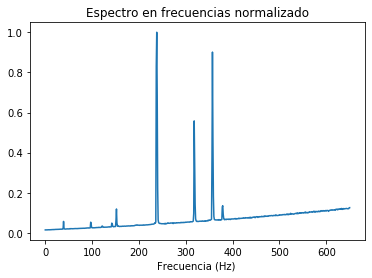

In [8]:
plt.plot(sp_f_norm)
plt.title('Espectro en frecuencias normalizado')
plt.xlabel(  'Frecuencia (Hz) ')#('r'$ \alpha$)')
plt.show()

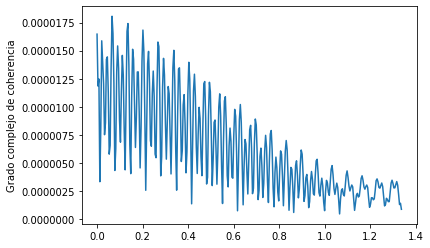

In [9]:
plt.plot(ts, P1)
plt.ylabel('Grado complejo de coherencia')
plt.show()

In [10]:
# Estimamos tc de la integral del modulo cuadrado del grado
# Normalizamos primero para que salga max unidad
P1_n=np.divide(P1,np.max(P1));
tc=np.multiply(np.sum(np.multiply(P1_n, P1_n)),Fs) #se multiplica por el valor delta tao, que coincide con Fs
lc=tc*3*10**8
print('tc= ',tc,'lc= ', lc)

tc=  150.68331741489547 lc=  45204995224.46864


# calculo directo

In [220]:
# np.min(lam)-np.max(lam)
#np.mean(lam)
landa=np.multiply(data[:,0],10**(-9))
lc=(np.mean(landa)**2)/(np.max(landa)-np.min(landa))
lc

7.009615384615383e-07

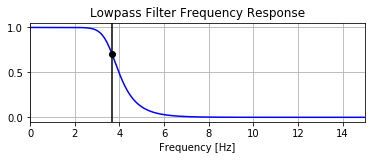

In [192]:
import numpy as np
from scipy.signal import butter, lfilter, freqz
import matplotlib.pyplot as plt


def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y


# Filter requirements.
order = 6
fs = 30.0       # sample rate, Hz
cutoff = 3.667  # desired cutoff frequency of the filter, Hz

# Get the filter coefficients so we can check its frequency response.
b, a = butter_lowpass(cutoff, fs, order)

# Plot the frequency response.
w, h = freqz(b, a, worN=8000)
plt.subplot(2, 1, 1)
plt.plot(0.5*fs*w/np.pi, np.abs(h), 'b')
plt.plot(cutoff, 0.5*np.sqrt(2), 'ko')
plt.axvline(cutoff, color='k')
plt.xlim(0, 0.5*fs)
plt.title("Lowpass Filter Frequency Response")
plt.xlabel('Frequency [Hz]')
plt.grid()


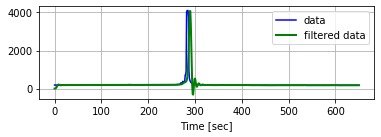

In [205]:
#https://stackoverflow.com/questions/25191620/creating-lowpass-filter-in-scipy-understanding-methods-and-units
# Demonstrate the use of the filter.
# First make some data to be filtered.
T = round(L)         # seconds
n = int(T ) # total number of samples
t = np.linspace(0, T, n, endpoint=False)
# "Noisy" data.  We want to recover the 1.2 Hz signal from this.
#data = np.sin(1.2*2*np.pi*t) + 1.5*np.cos(9*2*np.pi*t) + 0.5*np.sin(12.0*2*np.pi*t)

# Filter the data, and plot both the original and filtered signals.
y = butter_lowpass_filter(data[:,1], cutoff, fs, order)

plt.subplot(2, 1, 2)
plt.plot(t, data[:,1], 'b-', label='data')
plt.plot(t, y, 'g-', linewidth=2, label='filtered data')
plt.xlabel('Time [sec]')
plt.grid()
plt.legend()

plt.subplots_adjust(hspace=0.35)
plt.show()


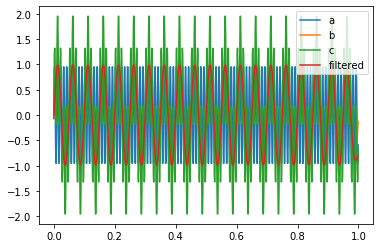

In [206]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 1000  # Sampling frequency
# Generate the time vector properly
t = np.arange(1000) / fs
signala = np.sin(2*np.pi*100*t) # with frequency of 100
plt.plot(t, signala, label='a')

signalb = np.sin(2*np.pi*20*t) # frequency 20
plt.plot(t, signalb, label='b')

signalc = signala + signalb
plt.plot(t, signalc, label='c')

fc = 30  # Cut-off frequency of the filter
w = fc / (fs / 2) # Normalize the frequency
b, a = signal.butter(5, w, 'low')
output = signal.filtfilt(b, a, signalc)
plt.plot(t, output, label='filtered')
plt.legend()
plt.show()